In [208]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import GRU  
from tensorflow.keras.layers import Bidirectional
import tensorflow as tf
from xgboost import XGBRegressor
from statsmodels.tsa.seasonal import STL
from sklearn.linear_model import LinearRegression

In [209]:
ts=pd.read_csv(r"C:\Users\kiril\OneDrive\Рабочий стол\jupyter_projects\Electric_Production.csv")

In [210]:
ts.head()

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151


In [211]:
ts.tail()

,DATE,IPG2211A2N
392,9/1/2017,98.6154
393,10/1/2017,93.6137
394,11/1/2017,97.3359
395,12/1/2017,114.7212
396,1/1/2018,129.4048


In [212]:
ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DATE        397 non-null    object 
 1   IPG2211A2N  397 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.3+ KB


In [213]:
ts.isna().sum()

DATE          0
IPG2211A2N    0
dtype: int64

In [214]:
ts['DATE']=pd.to_datetime(ts['DATE'])

# Нормализиум ряд по логарифмической шкале

In [215]:
ts.set_index('DATE', inplace=True)
ts1=ts.copy()
ts2=ts.copy()
ts1['IPG2211A2N']=np.log(ts1['IPG2211A2N'])

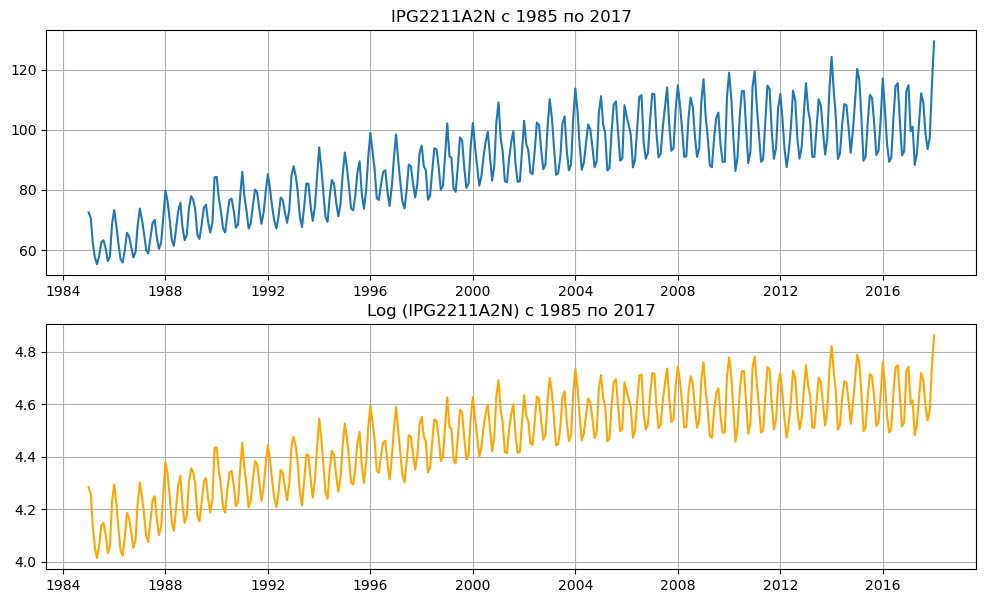

In [216]:
fig,ax=plt.subplots(nrows=2,ncols=1,figsize=(12,7))
ax=ax.flatten()

ax[0].plot(ts.index,ts)
ax[0].set_title('IPG2211A2N c 1985 по 2017')
ax[0].grid(True)

ax[1].plot(ts1.index,ts1,color='orange')
ax[1].set_title('Log (IPG2211A2N) c 1985 по 2017')
ax[1].grid(True)

In [217]:
ts['IPG2211A2N']=np.log(ts['IPG2211A2N'])
subset1 = ts['1985-01-01':'2007-12-31']
subset2 = ts['2008-01-01':'2018-12-31']
subset3=ts['1985-01-01':'1986-01-01']


C:\Users\kiril\AppData\Local\Temp\ipykernel_19580\1340769469.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
C:\Users\kiril\AppData\Local\Temp\ipykernel_19580\1340769469.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()
C:\Users\kiril\AppData\Local\Temp\ipykernel_19580\1340769469.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend()


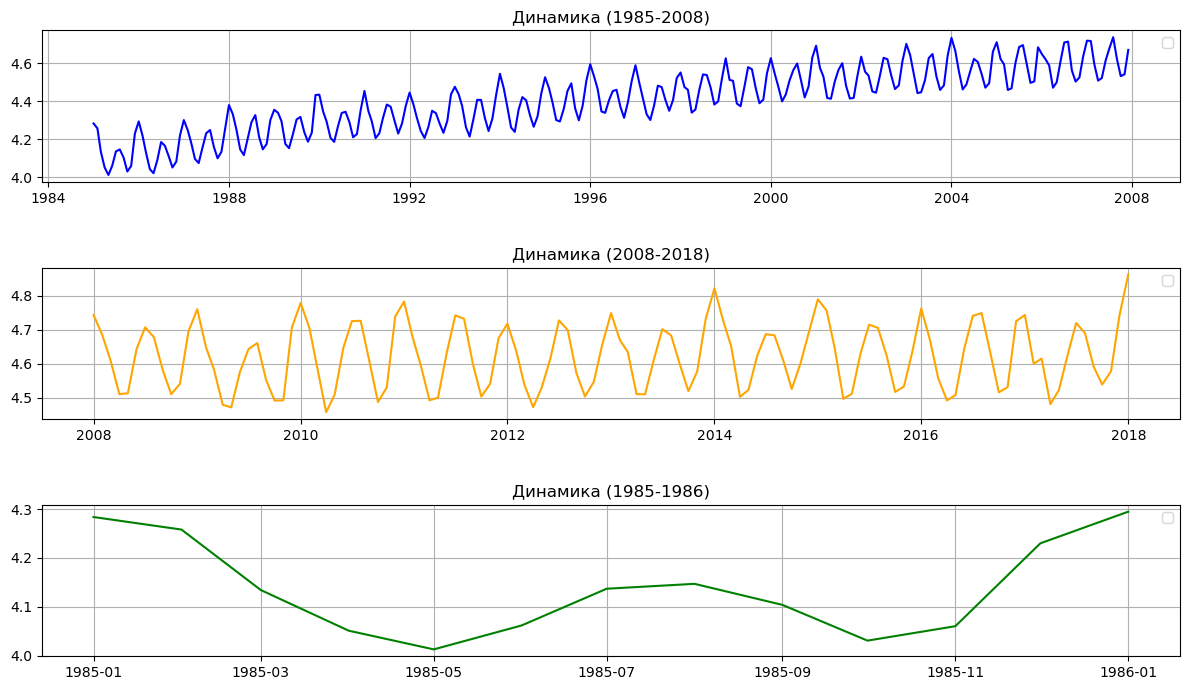

In [218]:

fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(12,7))
ax=ax.flatten()

ax[0].plot(subset1.index,subset1,color='blue')
ax[0].set_title('Динамика (1985-2008)')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(subset2.index,subset2,color='orange')
ax[1].set_title('Динамика (2008-2018)')
ax[1].legend()
ax[1].grid(True)

ax[2].plot(subset3.index,subset3,color='green')
ax[2].set_title('Динамика (1985-1986)')
ax[2].legend()
ax[2].grid(True)




plt.tight_layout(h_pad=3.0)


При сравнение 1-ого и 2-ого графика видно,что тренд в точке(2008)

В 3-ем графике видна сезонность

# Вычитание сезонности

In [219]:
ts1=ts.copy()
ts1['lag_12_diff']=ts1['IPG2211A2N'].diff(12)


In [220]:
ts1.head(20)

,IPG2211A2N,lag_12_diff
DATE,,
1985-01-01,4.283658,NaN
1985-02-01,4.258049,NaN
1985-03-01,4.134369,NaN
1985-04-01,4.051287,NaN
1985-05-01,4.013046,NaN
1985-06-01,4.062000,NaN
1985-07-01,4.137088,NaN
1985-08-01,4.147071,NaN
1985-09-01,4.104041,NaN


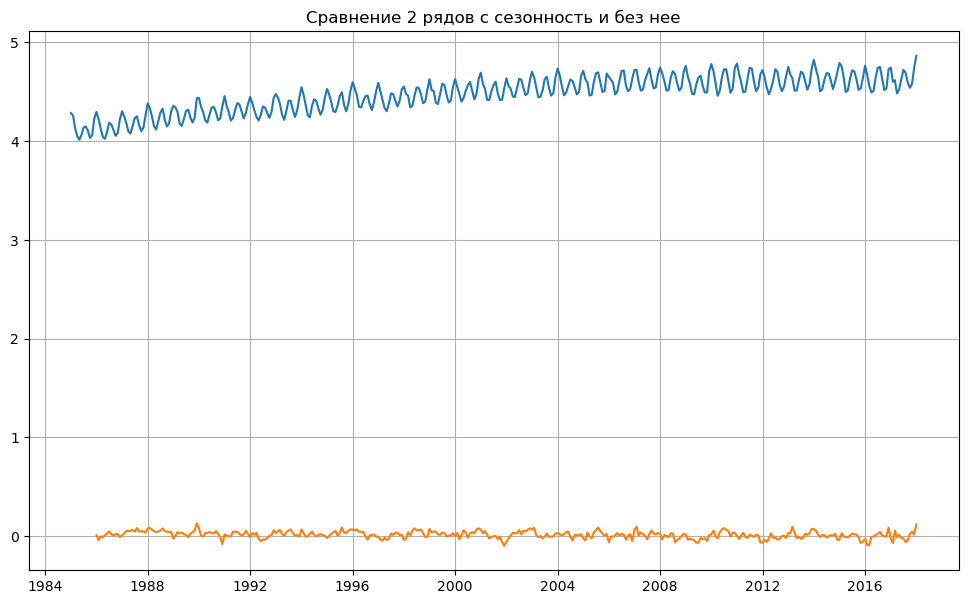

In [221]:
plt.figure(figsize=(12,7))

plt.plot(ts1.index,ts1)
plt.title('Сравнение 2 рядов с сезонность и без нее')
plt.grid(True)

# Выделаем отдельно ряд без сезонности

In [222]:
ts_diff12=ts1.drop('IPG2211A2N',axis=1).dropna()
ts_diff12.head(5)


,lag_12_diff
DATE,
1986-01-01,0.010980
1986-02-01,-0.038734
1986-03-01,-0.003659
1986-04-01,-0.007659
1986-05-01,0.008973


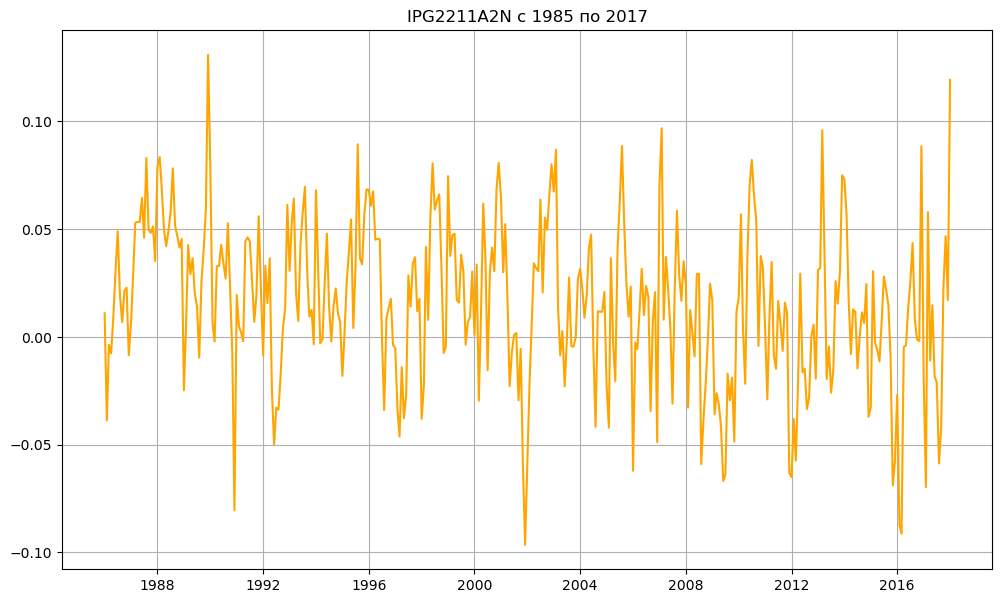

In [223]:

plt.figure(figsize=(12,7))

plt.plot(ts_diff12.index,ts_diff12,color='orange')
plt.title('IPG2211A2N c 1985 по 2017')
plt.grid(True)

# **Тест на стационарность**

In [224]:
result_ts = adfuller(ts_diff12['lag_12_diff'])

print(result_ts[1])


8.622788661526495e-06


***ряд стационарен***

# **Разделение данных**

In [225]:
dataset = ts_diff12.values.reshape(-1, 1)

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

win_sz = 12
X, y = create_sequences(dataset, win_sz)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [226]:
total_len = len(X)

test_split_idx = int(total_len * 0.85)
val_split_idx = int(total_len * 0.75)  

X_train, y_train = X[:val_split_idx], y[:val_split_idx]

X_val, y_val = X[val_split_idx:test_split_idx], y[val_split_idx:test_split_idx]

X_test, y_test = X[test_split_idx:], y[test_split_idx:]


# **GRU**

In [227]:

model = Sequential()
model.add(Input(shape=(win_sz, 1)))
model.add(GRU(64, activation='tanh', return_sequences=False))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(X_val, y_val), 
    verbose=1
)


Epoch 1/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 2/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 3/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.6593e-04 - val_loss: 0.0012
Epoch 4/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.6979e-04 - val_loss: 0.0011
Epoch 5/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.3115e-04 - val_loss: 0.0011
Epoch 6/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.2672e-04 - val_loss: 0.0011
Epoch 7/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.9819e-04 - val_loss: 0.0010
Epoch 8/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.8423e-04 - val_loss: 0.0010
Epoch 9/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.1052e-04 - val_loss: 0.0011
Epoch 10/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.0473e-04 - val_loss: 0.0011
Epoch 11/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.5241e-04 - val_loss: 0.0011
Epoch 12/60
18/18 ━━━━━━━━━━━━━━━━━

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
TEST MSE: 0.0013551984317348282
TEST MAE:  0.027833605185867527


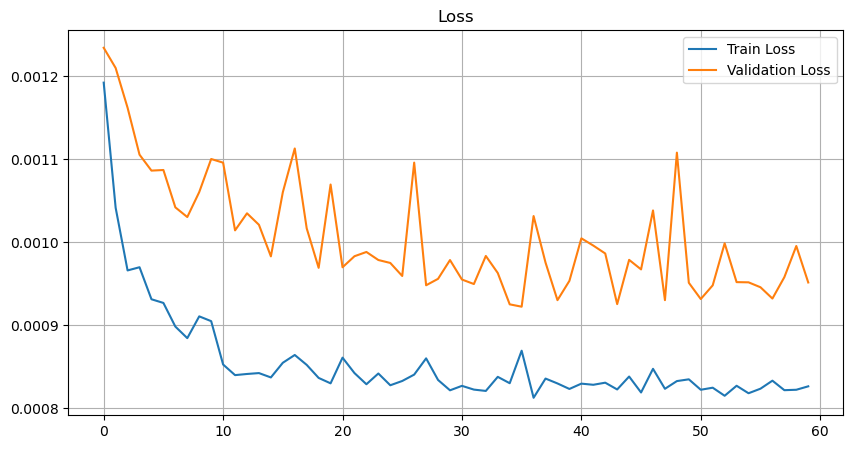

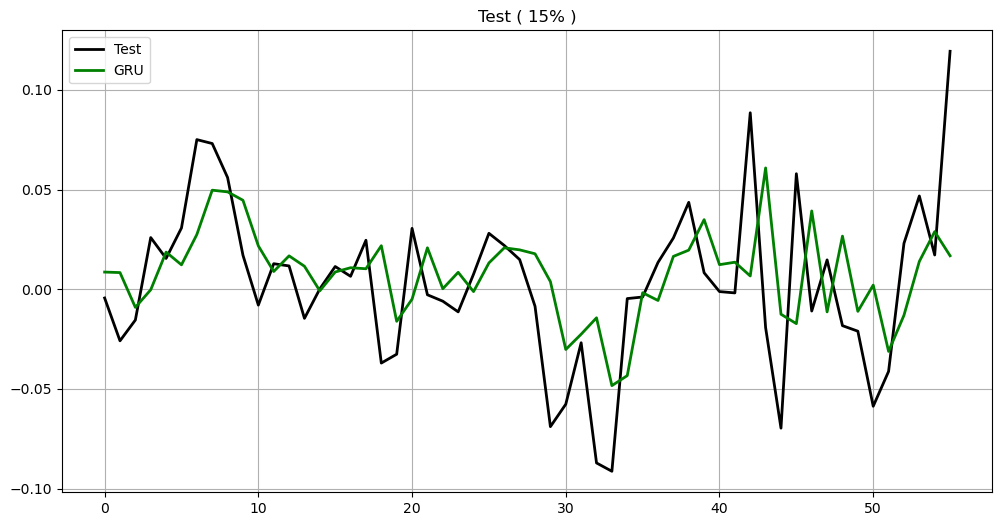

In [228]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.grid(True)

test_pred = model.predict(X_test)

mse = (mean_squared_error(y_test, test_pred))
mae = mean_absolute_error(y_test, test_pred)

print(f"TEST MSE: {mse}")
print(f"TEST MAE:  {mae}")

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Test', color='black', linewidth=2)
plt.plot(test_pred, label='GRU', color='green', linestyle='-', linewidth=2)
plt.title('Test ( 15% )')
plt.legend()
plt.grid(True)


# LSTM

In [229]:

model_lstm = Sequential()
model_lstm.add(Input(shape=(win_sz, 1)))
model_lstm.add(LSTM(64, activation='tanh', return_sequences=False))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 2/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 3/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 4/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0010 - val_loss: 0.0013
Epoch 5/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.9274e-04 - val_loss: 0.0011
Epoch 6/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.8296e-04 - val_loss: 0.0012
Epoch 7/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.5007e-04 - val_loss: 0.0013
Epoch 8/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.7201e-04 - val_loss: 0.0011
Epoch 9/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.3133e-04 - val_loss: 0.0011
Epoch 10/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.7243e-04 - val_loss: 0.0011
Epoch 11/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.5800e-04 - val_loss: 0.0013
Epoch 12/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6m

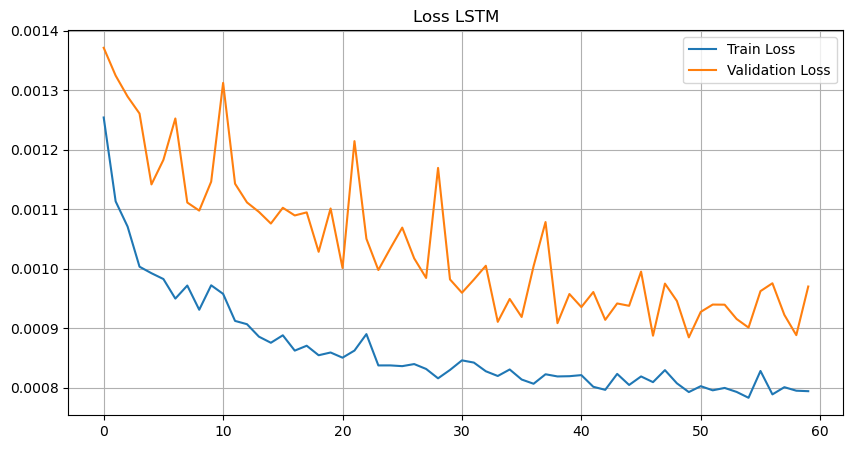

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
LSTM TEST MSE: 0.0015497045991986465
LSTM TEST MAE:  0.031077226081615974


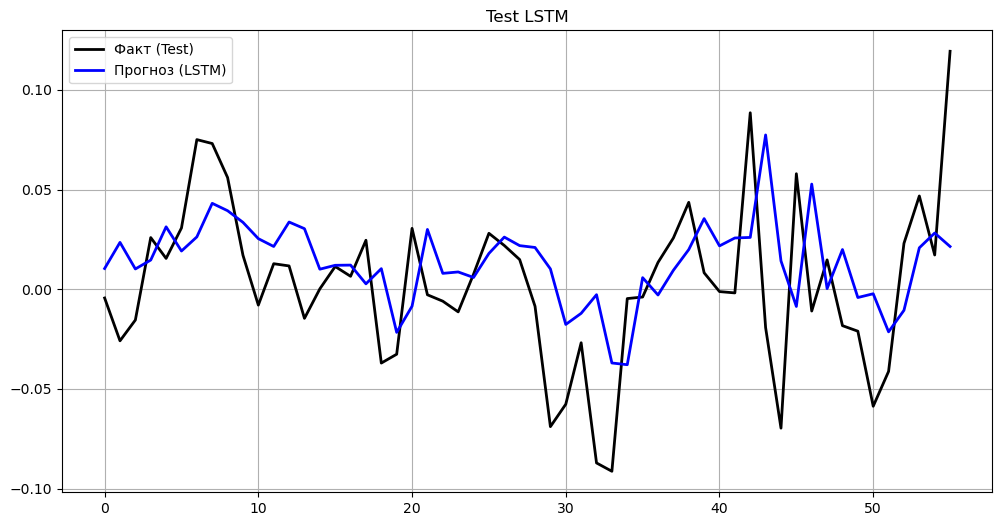

In [230]:
plt.figure(figsize=(10, 5))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('Loss LSTM')
plt.legend()
plt.grid(True)
plt.show()

test_pred_lstm = model_lstm.predict(X_test)

mse_lstm = mean_squared_error(y_test, test_pred_lstm)
mae_lstm = mean_absolute_error(y_test, test_pred_lstm)

print(f"LSTM TEST MSE: {mse_lstm}")
print(f"LSTM TEST MAE:  {mae_lstm}")

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Факт (Test)', color='black', linewidth=2)
plt.plot(test_pred_lstm, label='Прогноз (LSTM)', color='blue', linestyle='-', linewidth=2)
plt.title('Test LSTM')
plt.legend()
plt.grid(True)


# BLSTM

In [231]:
model_bi = Sequential()
model_bi.add(Input(shape=(win_sz, 1)))


model_bi.add(Bidirectional(LSTM(64, activation='tanh', return_sequences=False)))
model_bi.add(Dense(1))

model_bi.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history_bi = model_bi.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 2/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 3/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 4/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 5/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.7402e-04 - val_loss: 0.0011
Epoch 6/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.3766e-04 - val_loss: 0.0012
Epoch 7/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.3446e-04 - val_loss: 0.0011
Epoch 8/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.2500e-04 - val_loss: 0.0011
Epoch 9/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.1302e-04 - val_loss: 0.0011
Epoch 10/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.9444e-04 - val_loss: 0.0011
Epoch 11/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.9745e-04 - val_loss: 0.0012
Epoch 12/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 339ms/step
Bi-LSTM TEST RMSE: 0.03758102809502834
Bi-LSTM TEST MAE:  0.02935208962687646


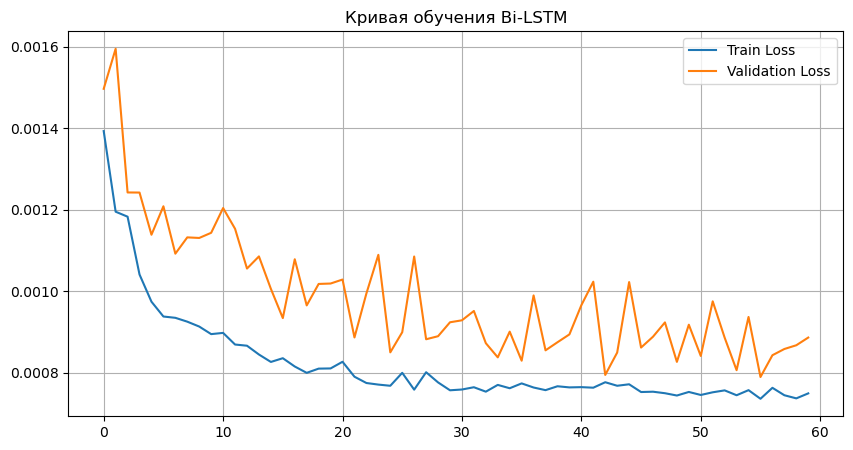

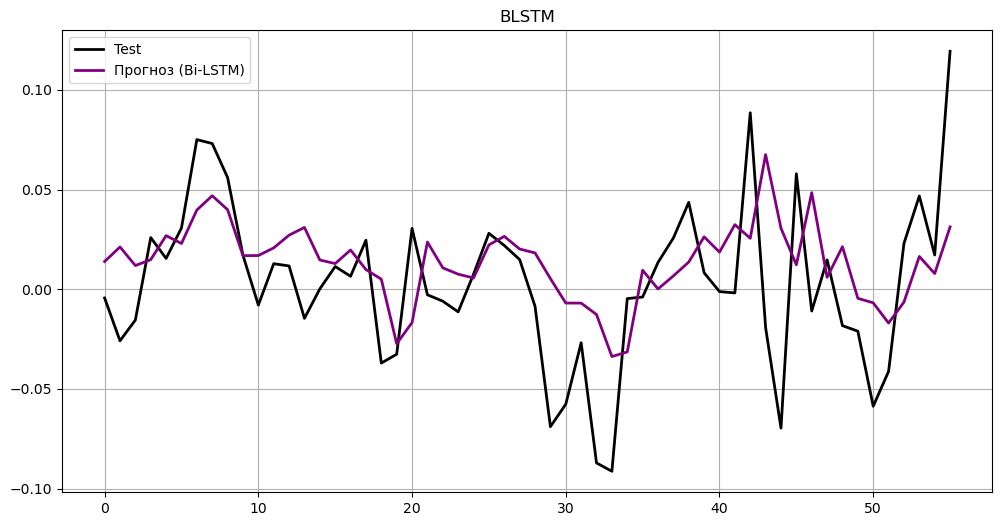

In [232]:
plt.figure(figsize=(10, 5))
plt.plot(history_bi.history['loss'], label='Train Loss')
plt.plot(history_bi.history['val_loss'], label='Validation Loss')
plt.title('Кривая обучения Bi-LSTM')
plt.legend()
plt.grid(True)



test_pred_bi = model_bi.predict(X_test)

rmse_bi = np.sqrt(mean_squared_error(y_test, test_pred_bi))
mae_bi = mean_absolute_error(y_test, test_pred_bi)

print(f"Bi-LSTM TEST RMSE: {rmse_bi}")
print(f"Bi-LSTM TEST MAE:  {mae_bi}")


plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Test', color='black', linewidth=2)
plt.plot(test_pred_bi, label='Прогноз (Bi-LSTM)', color='purple', linestyle='-', linewidth=2)
plt.title('BLSTM')
plt.legend()
plt.grid(True)


# XGBoost

In [233]:
X_train_xgb = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_val_xgb   = X_val.reshape(X_val.shape[0], X_val.shape[1])
X_test_xgb  = X_test.reshape(X_test.shape[0], X_test.shape[1])

In [234]:
model_xgb = XGBRegressor(
    n_estimators=1000,      
    learning_rate=0.001,    
    max_depth=6,            
    objective='reg:squarederror',
    random_state=42
)

In [235]:
X_train_xgb = X_train.reshape(X_train.shape[0], -1)
X_val_xgb   = X_val.reshape(X_val.shape[0], -1)
X_test_xgb  = X_test.reshape(X_test.shape[0], -1)

model_xgb.fit(
    X_train_xgb, y_train,  
    eval_set=[(X_train_xgb, y_train), (X_val_xgb, y_val)], 
    verbose=False
)

results = model_xgb.evals_result()


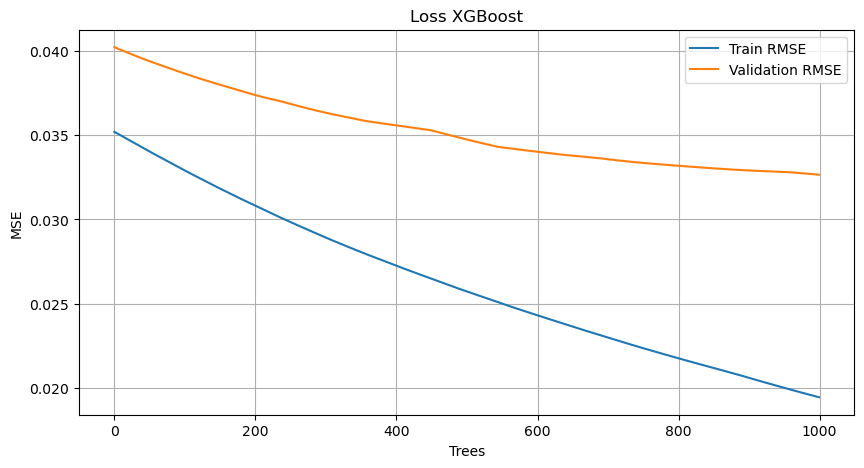

XGBoost TEST RMSE: 0.04039656600922352
XGBoost TEST MAE:  0.030391068183912334


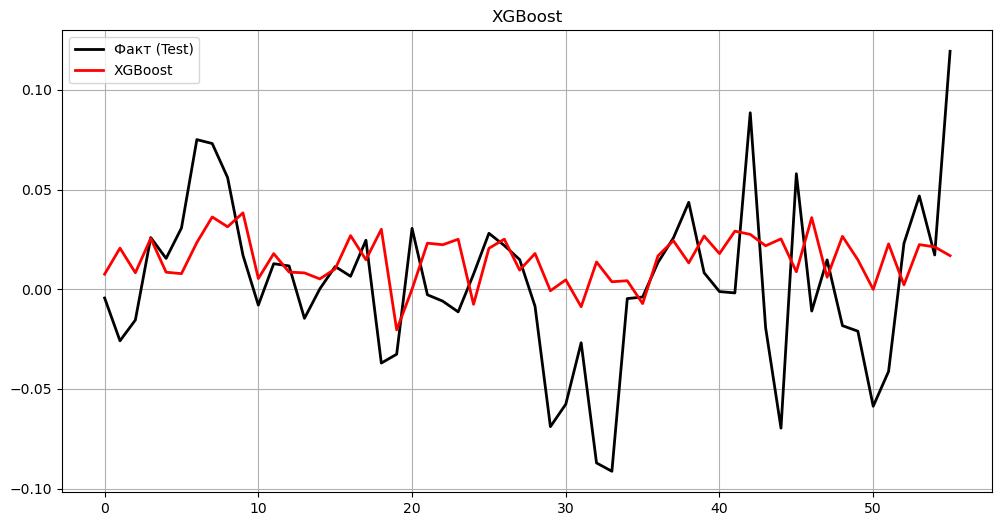

In [236]:
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['rmse'], label='Train RMSE')
plt.plot(results['validation_1']['rmse'], label='Validation RMSE')
plt.title('Loss XGBoost')
plt.xlabel('Trees')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

test_pred_xgb = model_xgb.predict(X_test_xgb)

rmse_xgb = np.sqrt(mean_squared_error(y_test, test_pred_xgb))
mae_xgb = mean_absolute_error(y_test, test_pred_xgb)

print(f"XGBoost TEST RMSE: {rmse_xgb}")
print(f"XGBoost TEST MAE:  {mae_xgb}")

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Факт (Test)', color='black', linewidth=2)
plt.plot(test_pred_xgb, label='XGBoost', color='red', linestyle='-', linewidth=2)
plt.title('XGBoost')
plt.legend()
plt.grid(True)


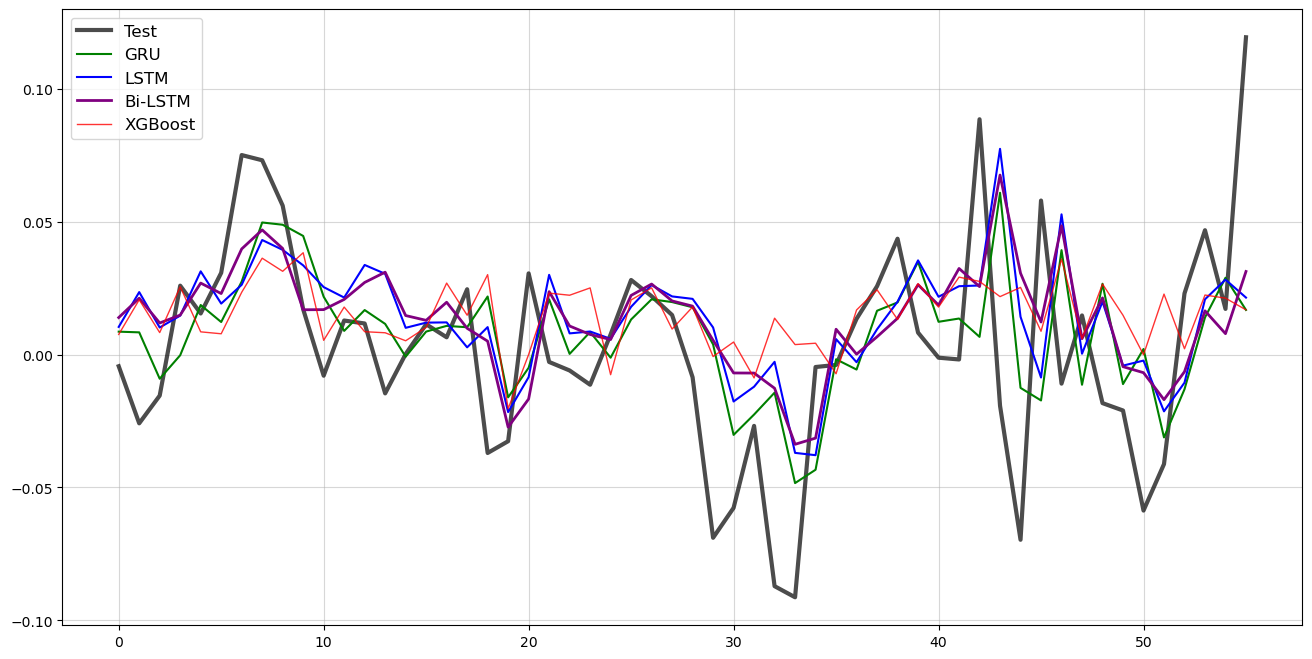

,Model,MSE,MAE
0,GRU,0.001355,0.027834
2,Bi-LSTM,0.001412,0.029352
1,LSTM,0.001550,0.031077
3,XGBoost,0.001632,0.030391


In [237]:
metrics = {
    'Model': ['GRU', 'LSTM', 'Bi-LSTM', 'XGBoost'],
    'MSE': [
        (mean_squared_error(y_test, test_pred)),
        (mean_squared_error(y_test, test_pred_lstm)),
        (mean_squared_error(y_test, test_pred_bi)),
        (mean_squared_error(y_test, test_pred_xgb))
    ],
    'MAE': [
        mean_absolute_error(y_test, test_pred),
        mean_absolute_error(y_test, test_pred_lstm),
        mean_absolute_error(y_test, test_pred_bi),
        mean_absolute_error(y_test, test_pred_xgb)
    ]
}

df_metrics = pd.DataFrame(metrics).sort_values(by='MSE')

plt.figure(figsize=(16, 8))

plt.plot(y_test, label='Test ', color='black', linewidth=3, alpha=0.7)

plt.plot(test_pred, label='GRU', color='green', linestyle='-', linewidth=1.5)
plt.plot(test_pred_lstm, label='LSTM', color='blue', linestyle='-', linewidth=1.5)
plt.plot(test_pred_bi, label='Bi-LSTM', color='purple', linestyle='-', linewidth=2)
plt.plot(test_pred_xgb, label='XGBoost', color='red', linestyle='-', linewidth=1, alpha=0.8)


plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

df_metrics.head()

# **Разложение на отдельные ряды и работа с ними**

# Логарифмирование

In [238]:
ts=pd.read_csv(r"C:\Users\kiril\OneDrive\Рабочий стол\jupyter_projects\Electric_Production.csv")
ts.head()
ts['log_production'] = np.log(ts['IPG2211A2N'])
ts.head()

,DATE,IPG2211A2N,log_production
0,1/1/1985,72.5052,4.283658
1,2/1/1985,70.6720,4.258049
2,3/1/1985,62.4502,4.134369
3,4/1/1985,57.4714,4.051287
4,5/1/1985,55.3151,4.013046


# Добавление признаков Фурье

In [239]:
def add_fourier_features(df, period, order):
    t = np.arange(len(df))
    for k in range(1, order + 1):

        df[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        df[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)
    return df



### Основная формула

Для каждого момента времени $t$ (индекс *0, 1, 2..*) и заданного периода $P$ (параметр *period*), значение сезонной компоненты $S(t)$ аппроксимируется формулой:

$$
S(t) \approx \sum_{k=1}^{N} \left( A_k \sin\left(\frac{2\pi k t}{P}\right) + B_k \cos\left(\frac{2\pi k t}{P}\right) \right)
$$

Где:
- $N$ — порядок разложения (параметр *order*). Количество пар волн, которые мы используем.
- $k$ — номер гармоники (от 1 до $N$).
    - $k=1$: Основная волна (период $P$).
    - $k=2$: Волна в 2 раза быстрее (период $P/2$).
    - $k=3$: Волна в 3 раза быстрее (период $P/3$).


In [240]:
order=3
period=12
data = add_fourier_features(ts, period=period, order=order)
data.head()

,DATE,IPG2211A2N,log_production,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
0,1/1/1985,72.5052,4.283658,0.000000,1.000000e+00,0.000000e+00,1.0,0.000000e+00,1.000000e+00
1,2/1/1985,70.6720,4.258049,0.500000,8.660254e-01,8.660254e-01,0.5,1.000000e+00,6.123234e-17
2,3/1/1985,62.4502,4.134369,0.866025,5.000000e-01,8.660254e-01,-0.5,1.224647e-16,-1.000000e+00
3,4/1/1985,57.4714,4.051287,1.000000,6.123234e-17,1.224647e-16,-1.0,-1.000000e+00,-1.836970e-16
4,5/1/1985,55.3151,4.013046,0.866025,-5.000000e-01,-8.660254e-01,-0.5,-2.449294e-16,1.000000e+00


# Добавление лагов shift'ом

In [241]:
lags = 12
for lag in range(1, lags + 1):
    data[f'lag_{lag}'] = data['log_production'].shift(lag)

In [242]:
data['trend_index'] = np.arange(len(data))
data.head()

,DATE,IPG2211A2N,log_production,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3,lag_1,...,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,trend_index
0,1/1/1985,72.5052,4.283658,0.000000,1.000000e+00,0.000000e+00,1.0,0.000000e+00,1.000000e+00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2/1/1985,70.6720,4.258049,0.500000,8.660254e-01,8.660254e-01,0.5,1.000000e+00,6.123234e-17,4.283658,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,3/1/1985,62.4502,4.134369,0.866025,5.000000e-01,8.660254e-01,-0.5,1.224647e-16,-1.000000e+00,4.258049,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,4/1/1985,57.4714,4.051287,1.000000,6.123234e-17,1.224647e-16,-1.0,-1.000000e+00,-1.836970e-16,4.134369,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,5/1/1985,55.3151,4.013046,0.866025,-5.000000e-01,-8.660254e-01,-0.5,-2.449294e-16,1.000000e+00,4.051287,...,4.283658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4


In [243]:
data.dropna(inplace=True)

In [244]:
data.isna().sum()

DATE              0
IPG2211A2N        0
log_production    0
sin_1             0
cos_1             0
sin_2             0
cos_2             0
sin_3             0
cos_3             0
lag_1             0
lag_2             0
lag_3             0
lag_4             0
lag_5             0
lag_6             0
lag_7             0
lag_8             0
lag_9             0
lag_10            0
lag_11            0
lag_12            0
trend_index       0
dtype: int64

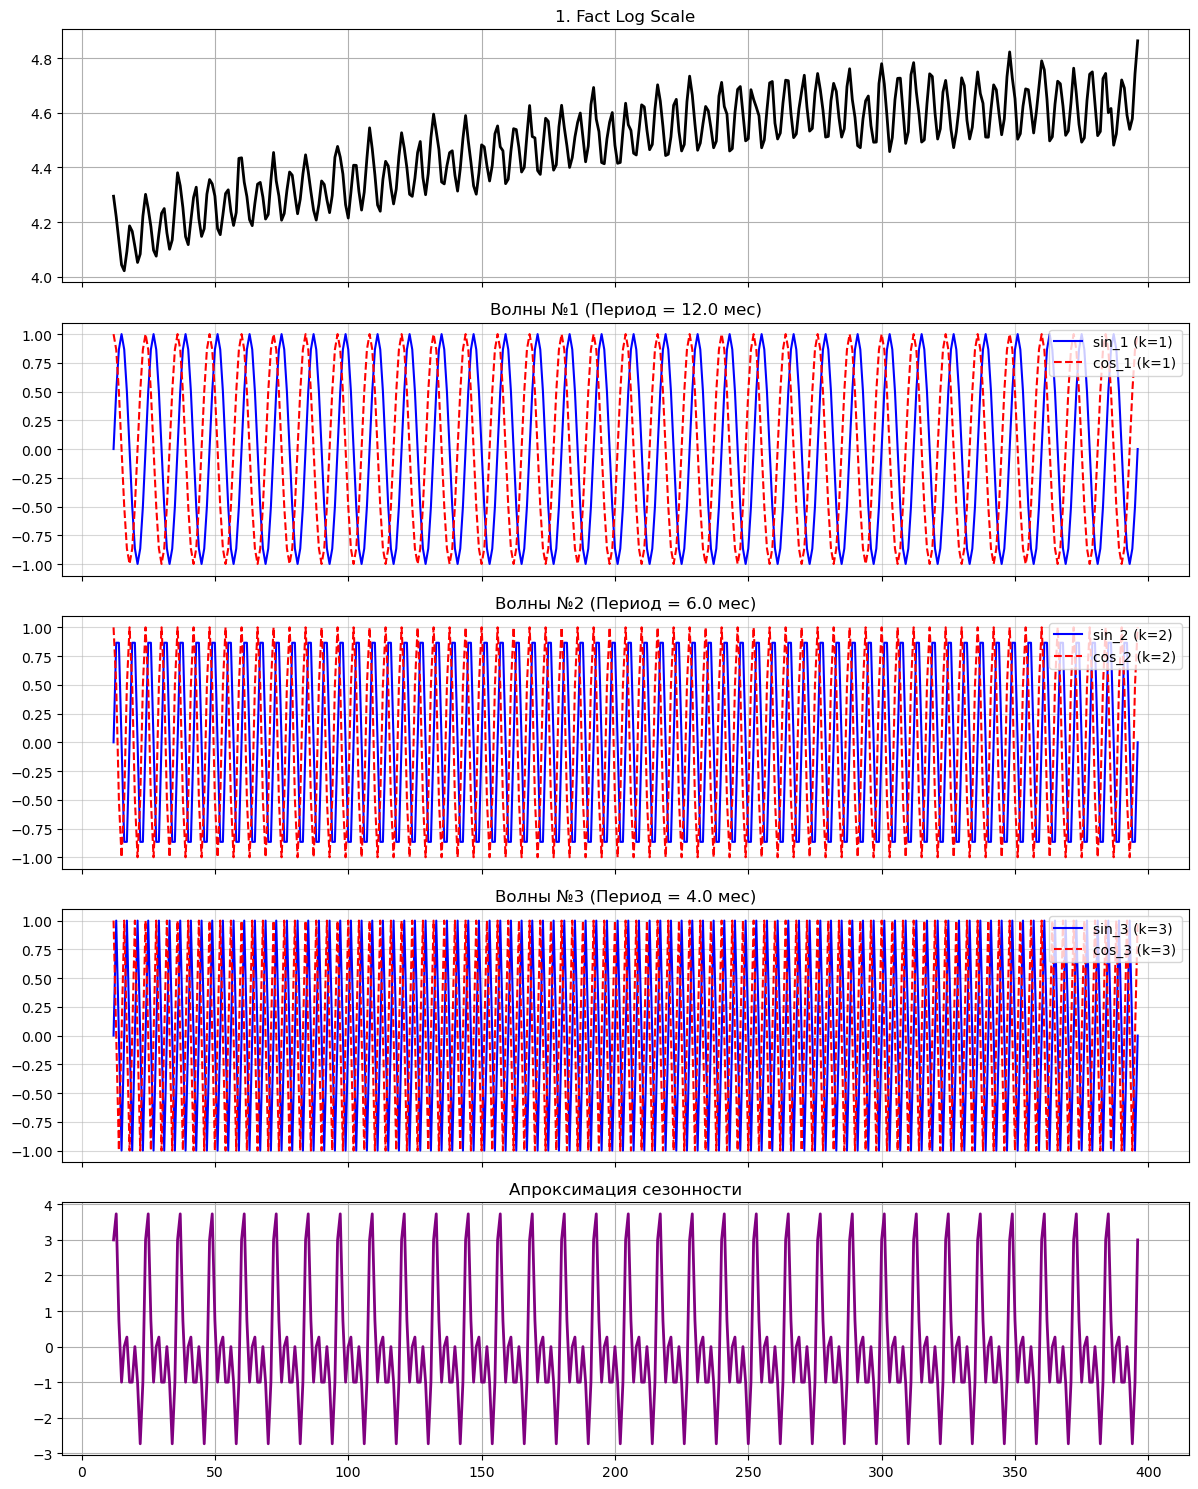

In [245]:
fig, axes = plt.subplots(order + 2, 1, figsize=(12, 3 * (order + 2)), sharex=True)

axes[0].plot(data['log_production'], color='black', linewidth=2)
axes[0].set_title('1. Fact Log Scale')
axes[0].grid(True)

for k in range(1, order + 1):
    ax = axes[k]
    ax.plot(data[f'sin_{k}'], label=f'sin_{k} (k={k})', color='blue', linestyle='-')
    ax.plot(data[f'cos_{k}'], label=f'cos_{k} (k={k})', color='red', linestyle='--')
    
    ax.set_title(f'Волны №{k} (Период = {period/k:.1f} мес)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.5)
simple_sum = np.zeros(len(data))
for k in range(1, order + 1):
    simple_sum += data[f'sin_{k}'] + data[f'cos_{k}']

ax_last = axes[-1]
ax_last.plot(simple_sum, color='purple', linewidth=2)
ax_last.set_title('Апроксимация сезонности')
ax_last.grid(True)

plt.tight_layout()

In [246]:
fourier_cols = [c for c in data.columns if 'sin_' in c or 'cos_' in c]


In [247]:
lag_cols = [c for c in data.columns if 'lag_' in c]
trend_col = ['trend_index']

resid_features = lag_cols + trend_col


In [248]:
test_size = int(len(data) * 0.15)
train_data = data.iloc[:-test_size].copy()
test_data = data.iloc[-test_size:].copy()

In [249]:
X_seas_train = train_data[fourier_cols].values
y_train = train_data['log_production'].values

X_seas_test = test_data[fourier_cols].values
y_test = test_data['log_production'].values

In [250]:
seas_model = LinearRegression()
seas_model.fit(X_seas_train, y_train)

seas_pred_train = seas_model.predict(X_seas_train)
seas_pred_test = seas_model.predict(X_seas_test)

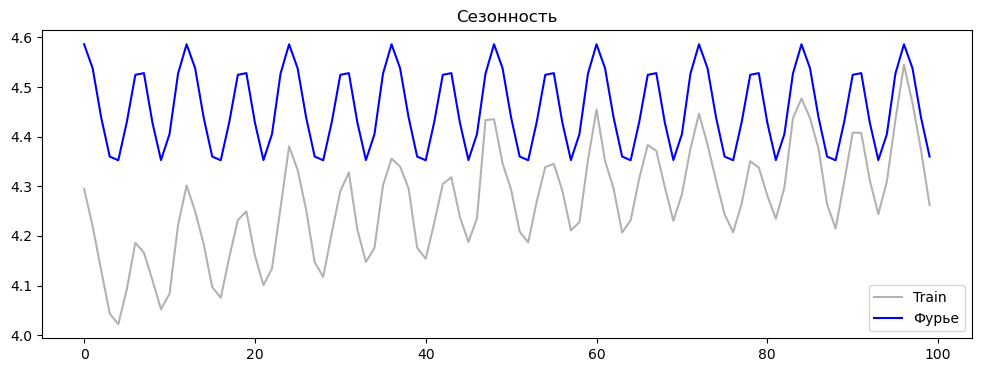

In [251]:
plt.figure(figsize=(12, 4))
plt.plot(y_train[:100], label='Train', color='black', alpha=0.3)
plt.plot(seas_pred_train[:100], label='Фурье', color='blue')
plt.title('Сезонность')
plt.legend()
plt.show()

In [252]:
resid_train = y_train - seas_pred_train
resid_test = y_test - seas_pred_test

X_resid_train = train_data[resid_features].values
X_resid_test = test_data[resid_features].values


# Проверка на стационарность

In [253]:

result_original = adfuller(data['log_production'].dropna())
print(f" p-value: {result_original[1]}")


 p-value: 0.027869168074959736


# **XGBoost**

In [254]:

xgb_resid = XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=5)
xgb_resid.fit(X_resid_train, resid_train)
resid_pred_xgb = xgb_resid.predict(X_resid_test)
final_pred_xgb = seas_pred_test + resid_pred_xgb

mse_xgb = mean_squared_error(y_test, final_pred_xgb)


# **GRU**

In [255]:
X_gru_train = X_resid_train.reshape(X_resid_train.shape[0], 1, X_resid_train.shape[1])
X_gru_test = X_resid_test.reshape(X_resid_test.shape[0], 1, X_resid_test.shape[1])

gru_model = Sequential([
    Input((1, X_resid_train.shape[1])),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
gru_model.compile(optimizer=Adam(0.001), loss='mse')
gru_model.fit(X_gru_train, resid_train, epochs=50, batch_size=16, verbose=1)

resid_pred_gru = gru_model.predict(X_gru_test).flatten()
final_pred_gru = seas_pred_test + resid_pred_gru


mse_gru = mean_squared_error(y_test, final_pred_gru)


Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3371
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2583 
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2309 
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2188 
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2046 
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1748 
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1808 
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1616 
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1450 
Epoch 10/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0962 
Epoch 11/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1153 
Epoch 12/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0841 
Epoch 13/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0669 
Epoch 14/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0656 
Epoch 15/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0586 
Epoch

# **LSTM**

In [256]:
lstm_model = Sequential([
    Input((1, X_resid_train.shape[1])), 
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(0.001), loss='mse')

lstm_model.fit(X_gru_train, resid_train, epochs=60, batch_size=16, verbose=1)

resid_pred_lstm = lstm_model.predict(X_gru_test).flatten()
final_pred_lstm = seas_pred_test + resid_pred_lstm 

Epoch 1/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1088
Epoch 2/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0551 
Epoch 3/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0438 
Epoch 4/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0362 
Epoch 5/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0300 
Epoch 6/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0201 
Epoch 7/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0158 
Epoch 8/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0113 
Epoch 9/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0127 
Epoch 10/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0100 
Epoch 11/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0101 
Epoch 12/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0072 
Epoch 13/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0082 
Epoch 14/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0068 
Epoch 15/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0060 
Epoch

# **BLSTM**

In [257]:

bilstm_model = Sequential([
    Input((1, X_resid_train.shape[1])),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.2),
    Dense(1)
])
bilstm_model.compile(optimizer=Adam(0.001), loss='mse')

bilstm_model.fit(X_gru_train, resid_train, epochs=60, batch_size=16, verbose=1)

resid_pred_bilstm = bilstm_model.predict(X_gru_test).flatten()
final_pred_bilstm = seas_pred_test + resid_pred_bilstm 

Epoch 1/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0776
Epoch 2/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0394
Epoch 3/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0367
Epoch 4/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0327 
Epoch 5/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0325 
Epoch 6/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0231
Epoch 7/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0213 
Epoch 8/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0181 
Epoch 9/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0159
Epoch 10/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0160 
Epoch 11/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0144 
Epoch 12/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0112
Epoch 13/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0077 
Epoch 14/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0071 
Epoch 15/60
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0054
Epoch 16/60

# **Финальные метрики**

In [258]:
mse_xgb = mean_squared_error(y_test, final_pred_xgb)
mse_gru = mean_squared_error(y_test, final_pred_gru)
mse_lstm = mean_squared_error(y_test, final_pred_lstm)
mse_bilstm = mean_squared_error(y_test, final_pred_bilstm)

print(f"XGBoost: {mse_xgb}")
print(f"GRU:     {mse_gru}")
print(f"LSTM:    {mse_lstm}")
print(f"Bi-LSTM: {mse_bilstm}")

XGBoost: 0.0013863879674407772
GRU:     0.00252694138957742
LSTM:    0.0013683545888908178
Bi-LSTM: 0.0014052693880421945


# **Финальный график сравнения**

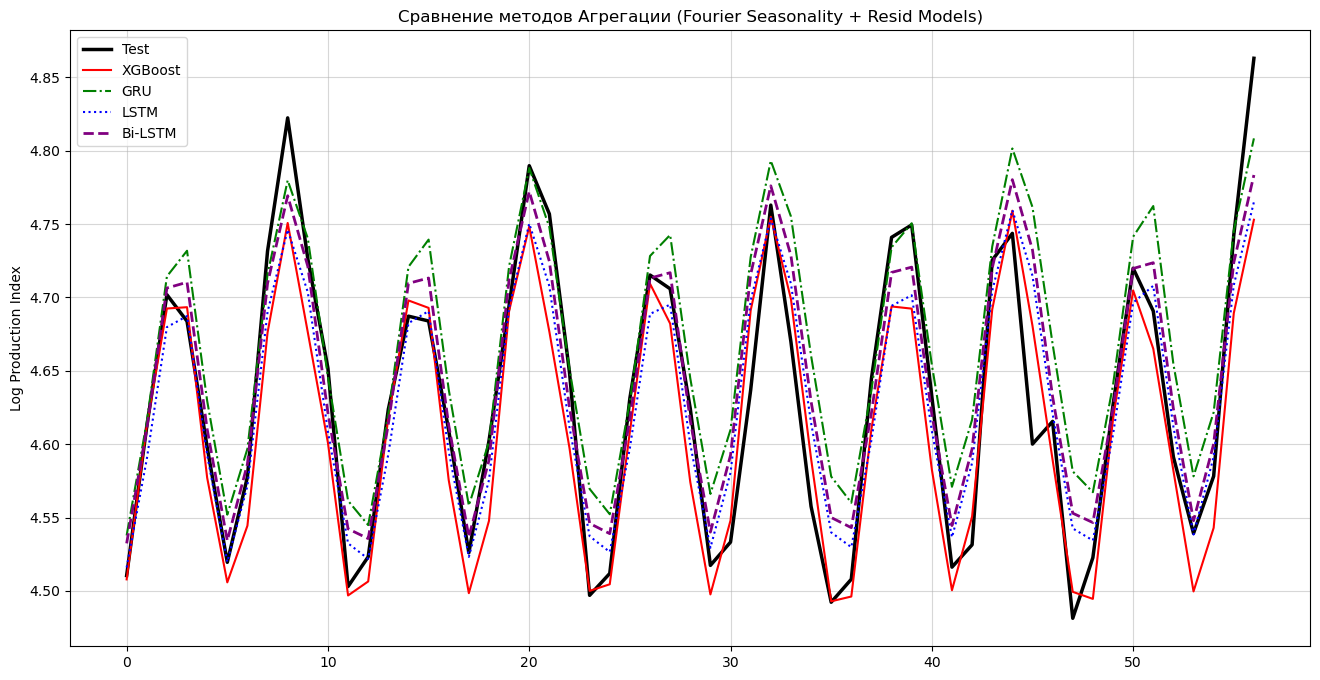

In [259]:

plt.figure(figsize=(16, 8))

plt.plot(y_test, label='Test', color='black', linewidth=2.5, alpha=1)


plt.plot(final_pred_xgb, label='XGBoost', color='red', linestyle='-', linewidth=1.5)
plt.plot(final_pred_gru, label='GRU', color='green', linestyle='-.', linewidth=1.5)
plt.plot(final_pred_lstm, label='LSTM', color='blue', linestyle=':', linewidth=1.5)
plt.plot(final_pred_bilstm, label='Bi-LSTM', color='purple', linestyle='--', linewidth=2)

plt.title('Сравнение методов Агрегации (Fourier Seasonality + Resid Models)')
plt.ylabel('Log Production Index')
plt.legend()
plt.grid(True, alpha=0.5)

# **Анализ двух подходов к прогнозированию временных рядов**

## 1. Обзор подходов

### Подход 1: Прямое дифференцирование
Метод предполагает удаление тренда и сезонности путём 12-месячного дифференцирования временного ряда логарифмированных данных: $z_t = y_t - y_{t-12}$. Полученный стационарный ряд верифицируется ADF-тестом. На дифференцированных данных обучаются четыре модели GRU, LSTM, Bi-LSTM, XGBoost .

> Разделение данных: 75% обучение / 10% валидация / 15% тест.

### Подход 2: Разложение Фурье
Метод базируется на явном разделении временного ряда на компоненты. Сезонная компонента аппроксимируется рядом Фурье с периодом 12 месяцев и порядком 3. Остаточная компонента включает тренд и шум. Cезонность моделируется линейной регрессией на Фурье-признаках и тренде, остаток — отдельными моделями. Финальный прогноз получается суммированием обеих компонент. Также используются 4 вышеописанных модели.

>Разделение: 85% обучение / 15% тест.

**Подход 2 лучше подхода 1:**

- **Сохранение полной информации.** Подход 2 работает с исходными данными полностью, не теряя информацию при обработке. Подход 1 необратимо удаляет первые 12 наблюдений через дифференцирование, сокращая размер обучающей выборки и тестовой базы данных.

- **Подход 2 явно разделяет компоненты временного ряда** (сезонность, тренд, остаток), что позволяет анализировать каждую компоненту отдельно и объяснять результаты. Подход 1 работает как чёрный ящик, скрывая внутреннюю структуру данных.


- **Гибкость и адаптивность.** Подход 2 позволяет регулировать параметры разложения (порядок Фурье, количество лагов, тренд), адаптируя модель к характеристикам данных. Подход 1 использует фиксированное 12-месячное дифференцирование без возможности настройки.


**Подход 2 хуже подхода 1:**


- **Вычислительная сложность.** Подход 2 требует расчёта Фурье-признаков, подготовки дополнительных лагов и тренда, а также двухэтапного моделирования. Подход 1 использует простое 12-месячное дифференцирование, что значительно быстрее в реализации и обучении.



- **Потребность в настройке параметров.** Подход требует подбора порядка Фурье, количества лагов и других гиперпараметров. Неправильный выбор параметров может привести к снижению производительности. Подход 1 использует фиксированную стратегию без необходимости в такой настройке.


